# Сравнение VQ-методов и каузальной стабилизации команд Unitree G1

In [47]:
from pathlib import Path
from itertools import product
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
from scipy.optimize import linear_sum_assignment
from sklearn.cluster import KMeans
from sklearn.metrics import confusion_matrix
from constants import (RANDOM_STATE, WINDOW_STEP_SECONDS, N_ACTION_PROTOTYPES, N_SUBACTION_PROTOTYPES, NEUTRAL_ID, ACTIVE_COMMAND_IDS, COMMANDS, MAJORITY_WINDOWS, CONFIRMATION_WINDOWS, CONFIDENCE_THRESHOLDS, EVENT_IOU_THRESHOLD, RECORD_IDS, TRAIN_RECORD_IDS, CONF_RECORD_IDS, TEST_RECORD_IDS)
from matplotlib.patches import Patch

DATA_DIR, RESULTS_DIR = Path('dataset'), Path('results')
FIG_DIR = RESULTS_DIR / 'figures'; FIG_DIR.mkdir(parents=True, exist_ok=True)
LABEL_NAMES = {0: 'DISTRACTOR', 1: 'NEUTRAL', 2: 'FORWARD', 3: 'LEFT', 4: 'RIGHT'}
ALL_LABELS = np.array(sorted(LABEL_NAMES))

np.set_printoptions(precision=3, suppress=True); sns.set_theme(style='whitegrid', context='notebook')

## Загрузка датасетов

In [48]:
def load_split(name):
    df = pd.read_csv(DATA_DIR / f'{name}.csv')
    meta_columns = ['record_id', 'window_start_frame', 'window_end_frame']
    pc_columns = [c for c in df.columns if c.startswith('pc')]

    return df[pc_columns].to_numpy(float), df['target'].to_numpy(int), df[meta_columns].copy()

In [49]:
def record_slices(record_ids, meta):
    ids = meta['record_id'].to_numpy()
    starts = np.r_[0, np.flatnonzero(ids[1:] != ids[:-1]) + 1]
    stops = np.r_[starts[1:], len(ids)]
    actual_ids = tuple(ids[starts])

    assert actual_ids == tuple(record_ids), (actual_ids, record_ids)
    slices = [slice(start, stop) for start, stop in zip(starts, stops)]
    return slices, [sl.stop - sl.start for sl in slices]

In [50]:
X_train, y_train, train_meta = load_split('train')
X_conf, y_conf, conf_meta = load_split('conf')
X_test, y_test, test_meta = load_split('test')

train_slices, train_sizes = record_slices(TRAIN_RECORD_IDS, train_meta)
conf_slices, conf_sizes = record_slices(CONF_RECORD_IDS, conf_meta)
test_slices, test_sizes = record_slices(TEST_RECORD_IDS, test_meta)

In [51]:
print(f'train={X_train.shape}, conf={X_conf.shape}, test={X_test.shape}')
print('Окон по записям:', dict(zip(RECORD_IDS, [*train_sizes, *conf_sizes, *test_sizes])))
display(pd.DataFrame({'split': ['train', 'conf', 'test'], 'windows': [len(y_train), len(y_conf), len(y_test)]}).assign(duration_min=lambda d: d.windows * WINDOW_STEP_SECONDS / 60))

train=(5773, 16), conf=(1946, 16), test=(3834, 16)
Окон по записям: {'2_9': 1920, '2_10': 1928, '2_12': 1925, '2_14': 1946, '2_15': 1917, '2_16': 1917}


,split,windows,duration_min
0,train,5773,9.621667
1,conf,1946,3.243333
2,test,3834,6.390000


## Обучение VQ и сопоставление прототипов

Кластеры сопоставляются с четырьмя размеченными состояниями команды венгерским алгоритмом на train. DISTRACTOR в обучение прототипов не входит. VQ без отдельного reject-класса обязан ошибочно активироваться вне словаря команд, и это учитывают метрики. (хороший вопрос именно так нужно считать либо нет)

In [52]:
def fit_cluster_mapping(cluster_ids, labels, n_clusters):
    score = np.zeros((n_clusters, len(COMMANDS)), dtype=int)
    for k in range(n_clusters):
        for j, c in enumerate(COMMANDS):
            score[k, j] = np.sum((cluster_ids == k) & (labels == c))

    rows, cols = linear_sum_assignment(-score)
    mapping = {int(k): int(COMMANDS[j]) for k, j in zip(rows, cols)}

    if len(mapping) != n_clusters or any(score[k].sum() == 0 for k in mapping):
        raise RuntimeError('Не удалось однозначно сопоставить VQ-прототипы')
    return mapping, score

In [53]:
mask = y_train != 0 # выкидываем DISTRACTOR из обучения
X_cmd, y_cmd = X_train[mask], y_train[mask]

# одноуровневый паплайн

one_vq = KMeans(n_clusters=N_ACTION_PROTOTYPES, n_init=20, random_state=RANDOM_STATE).fit(X_cmd)
one_mapping, one_score = fit_cluster_mapping(one_vq.labels_, y_cmd, N_ACTION_PROTOTYPES)

# двухуроыенвыый паплайн

sub_vq = KMeans(n_clusters=N_SUBACTION_PROTOTYPES, n_init=20, random_state=RANDOM_STATE).fit(X_cmd)
sub_weights = np.bincount(sub_vq.labels_, minlength=N_SUBACTION_PROTOTYPES).astype(float)

action_vq = KMeans(n_clusters=N_ACTION_PROTOTYPES, n_init=20, random_state=RANDOM_STATE).fit(sub_vq.cluster_centers_, sample_weight=sub_weights)
z_to_a = action_vq.labels_

two_mapping, two_score = fit_cluster_mapping(z_to_a[sub_vq.labels_], y_cmd, N_ACTION_PROTOTYPES)

In [54]:
def predict_one_level(X):
    return np.array([one_mapping[int(k)] for k in one_vq.predict(X)], dtype=int)

def predict_two_level(X, with_confidence=False):
    dz = sub_vq.transform(X)
    da = np.column_stack([dz[:, z_to_a == a].min(axis=1) for a in range(N_ACTION_PROTOTYPES)])
    order = np.argsort(da, axis=1)
    best = order[:, 0]

    pred = np.array([two_mapping[int(a)] for a in best], dtype=int)
    d1, d2 = da[np.arange(len(X)), best], da[np.arange(len(X)), order[:, 1]]
    confidence = np.clip(1 - d1 / (d2 + 1e-12), 0, 1)

    return (pred, confidence) if with_confidence else pred

In [55]:
print('Одноуровневое сопоставление:', one_mapping)
display(pd.DataFrame(one_score, columns=[LABEL_NAMES[c] for c in COMMANDS]))
print('Двухуровневое сопоставление:', two_mapping, '; z->a:', z_to_a.tolist())
print('Размеры поддействий:', sub_weights.astype(int).tolist())

Одноуровневое сопоставление: {0: 1, 1: 3, 2: 2, 3: 4}


,NEUTRAL,FORWARD,LEFT,RIGHT
0,1219,50,30,44
1,27,13,534,9
2,32,750,27,15
3,18,43,38,602


Двухуровневое сопоставление: {0: 4, 1: 1, 2: 2, 3: 3} ; z->a: [2, 0, 0, 3, 1, 1, 2, 1]
Размеры поддействий: [738, 110, 626, 563, 592, 357, 129, 336]


## Каузальные фильтры и метрики

Event-F1 использует однозначное сопоставление сегментов классов с IoU >= 0.10. Ложная активация - непарное предсказанное активное событие, двойная команда - каждый повторный старт той же команды внутри одного эталонного активного сегмента. Задержка измеряется для найденных событий. Кроме того двойственность возможна в понятии двойных команд мы учитываем просто bool мол состоялась ли двойная команда в интервале, или количество колибаний, я посчитал количество кажется это логичнее. 

In [56]:
def causal_majority(labels, window):
    """
        Cкользящее большинство по последним window окнам
        Вход:
            labels - метки классов
            window - размер окна
        Выход:
            out - большинство по последним window окнам
    """
    out = np.empty_like(labels)
    for t in range(len(labels)):
        v, n = np.unique(labels[max(0, t - window +  1): t + 1], return_counts=True)
        out[t] = v[np.argmax(n)]
    return out

In [57]:
def transition_automaton(labels, confidence, confirmations, threshold):
    """
        Каузальный автомат переходов NEUTRAL -> TRANSITION -> ACTIVE(command).
        Новая команда активируется только после confirmations подряд идущих
        одинаковых решений с уверенностью не ниже threshold.

        Вход:
            labels - метки классов от квантования (N,)
            confidence - уверенность на каждом окне [0, 1] (N,)
            confirmations - число подтверждений подряд (1, 3, 5)
            threshold - порог уверенности, ниже которого окно игнорируется

        Выход:
            out - подтверждённые команды (N,)
            states - состояния автомата (N,): 'NEUTRAL', 'TRANSITION', 'ACTIVE_<name>'
    """
    current, pending, run = NEUTRAL_ID, None, 0
    out, states = np.empty_like(labels), []

    for observed, conf in zip(labels, confidence):
        proposed = int(observed) if conf >= threshold else current

        if proposed == current: # ничерта не поменялось новых кандидатов нет
            pending, run = None, 0
            state = 'NEUTRAL' if current == NEUTRAL_ID else f'ACTIVE_{LABEL_NAMES[current]}'
        else: # появился новый кандидат на смену current
            run = run + 1 if pending == proposed else 1
            pending = proposed

            if run >= confirmations: # опа меняем
                current, pending, run = proposed, None, 0
                state = 'NEUTRAL' if current == NEUTRAL_ID else f'ACTIVE_{LABEL_NAMES[current]}'
            else: # начинаем преход
                state = 'TRANSITION'

        out[len(states)] = current
        states.append(state)

    return out, np.asarray(states, dtype=object)

In [58]:
def apply_per_record(labels, slices, fn, confidence=None):
    """
        Применяет каузальный фильтр fn к каждой записи отдельно, чтобы границы
        между записями не пересекались и каузальность не нарушалась.

        Вход:
            labels - предсказания модели (N,)
            slices - список slice(start, stop) по одной на запись
            fn - каузальный фильтр: causal_majority или transition_automaton
            confidence - уверенности (N,) для методов, которым они нужны.
                        None, если фильтр их не использует.
        Выход:
            out - предсказания после фильтрации (N,), склеенные в один массив
            states - состояния (N,). Если fn вернул кортеж (out, states) —
                    берём состояния оттуда. Иначе заполняем 'FILTERED'.
    """
    out, states = np.empty_like(labels), np.empty(len(labels), dtype=object)

    for sl in slices:
        answer = fn(labels[sl]) if confidence is None else fn(labels[sl], confidence[sl])
    
        if isinstance(answer, tuple):
            out[sl], states[sl] = answer
        else:
            out[sl], states[sl] = answer, 'FILTERED'

    return out, states

In [59]:
def events(labels):
    """
        Находит непрерывные отрезки активных команд в последовательности меток.

        Пробегает по массиву меток слева направо и группирует подряд идущие
        одинаковые значения в события. Событием считается непрерывный отрезок,
        на котором метка не меняется. В результат попадают только отрезки,
        чья метка принадлежит ACTIVE_COMMAND_IDS (FORWARD, LEFT, RIGHT),
        то есть реальные команды. NEUTRAL и DISTRACTOR игнорируются —
        они не являются активными командами.

        Вход:
            labels - метки классов (N,)
        Выход:
            answer - список кортежей (command, start, end):
                    command - код команды из ACTIVE_COMMAND_IDS
                    start - индекс первого окна отрезка (включительно)
                    end - индекс после последнего окна (эксклюзивно)
    """
    answer, start = [], 0

    for t in range(1, len(labels) + 1):
        if t == len(labels) or labels[t] != labels[start]:
            if labels[start] in ACTIVE_COMMAND_IDS:
                answer.append((int(labels[start]), start, t))
            start = t

    return answer

In [60]:
def event_matches(reference, predicted):
    """
        Сопоставляет предсказанные события с эталонными по IoU-перекрытию.

        Событие считается совпавшим, если:
        1. метки совпадают (одна и та же команда),
        2. IoU (intersection over union) пересечения отрезков >= EVENT_IOU_THRESHOLD.

        Из всех кандидатов для каждого предсказанного события выбирается тот
        эталонный отрезок, у которого IoU максимальный. Жадное сопоставление:
        каждое эталонное событие может быть сопоставлено не более одного раза.

        Вход:
            reference - эталонные события [(label, start, end), ...]
            predicted - предсказанные события [(label, start, end), ...]
        Выход:
            matches - список пар (ref_index, pred_index) для совпавших событий.
                    Индексы указывают на позиции в исходных списках.
    """
    available, matches = set(range(len(reference))), []

    for pi, (lab, ps, pe) in enumerate(predicted):
        candidates = []
        for ri in available:
            rlab, rs, re = reference[ri]
            inter = max(0, min(pe, re)-max(ps, rs))
            union = max(pe, re)-min(ps, rs)

            if lab == rlab and inter / union >= EVENT_IOU_THRESHOLD:
                candidates.append((inter / union, ri))

        if candidates:
            _, ri = max(candidates); available.remove(ri); matches.append((ri, pi))

    return matches

In [61]:
def evaluate(y_true, y_pred, slices):
    """
        Считает все метрики задания на наборе записей.

        Вход:
            y_true - эталонные метки (N,)
            y_pred - предсказанные метки (N,)
            slices - список slice(start, stop) по одной на запись
        Выход:
            dict с метриками:
                frame_accuracy - покадровая точность (п.10.1)
                event_precision, event_recall - точность/полнота по событиям
                event_f1 - F1 по событиям (п.10.2)
                false_activations_per_min - ложные активации в минуту (п.10.3)
                median_delay_s - медианная задержка (п.10.4)
                p95_delay_s - 95-й перцентиль задержки (п.10.5)
                double_commands_per_transition - двойные команды на переход (п.10.6)
                missed_commands - пропущенные команды (п.10.7)
                reference_events, predicted_events - вспомогательные счётчики
    """
    refs, preds, matches, offset = [], [], [], 0

    for sl in slices:
        ref, pred = events(y_true[sl]), events(y_pred[sl])
        local = event_matches(ref, pred)

        ref_base, pred_base = len(refs), len(preds)

        # надо сделать офсет так как по факту мы взяли 6 записей и склеили в 3
        refs.extend([(a, s + offset, e + offset) for a, s, e in ref])
        preds.extend([(a, s + offset, e + offset) for a, s, e in pred])
        matches.extend([(ri + ref_base, pi + pred_base) for ri, pi in local])

        offset += sl.stop - sl.start

    tp, nr, npred = len(matches), len(refs), len(preds)
    precision = tp / npred if npred else 0
    recall = tp / nr if nr else 0


    f1 = 2 * precision * recall / (precision + recall) if precision + recall else 0
    delays = [max(0, preds[pi][1] - refs[ri][1]) * WINDOW_STEP_SECONDS for ri, pi in matches]
    doubles = sum(max(0, sum(a == ra and rs <= ps < re for a, ps, _ in preds) - 1) for ra, rs, re in refs)
    duration_min = len(y_true) * WINDOW_STEP_SECONDS / 60

    return {'frame_accuracy': np.mean(y_true == y_pred), 'event_precision': precision, 'event_recall': recall, 'event_f1': f1,
            'false_activations_per_min': (npred - tp) / duration_min, 'median_delay_s': np.median(delays) if delays else np.nan,
            'p95_delay_s': np.percentile(delays, 95) if delays else np.nan, 'double_commands_per_transition': doubles / nr if nr else np.nan,
            'missed_commands': nr - tp, 'reference_events': nr, 'predicted_events': npred}

## Настройка только на conf

Будем выбирать так: максимальный Event-F1, затем минимум ложных активаций/мин, затем минимум 95%-й задержки. Соритируем по "лексеграфическому" порядку

In [62]:
one_conf = predict_one_level(X_conf)
two_conf, two_confidence = predict_two_level(X_conf, with_confidence=True)

rows = []
for window in MAJORITY_WINDOWS:
    pred, _ = apply_per_record(one_conf, conf_slices, lambda x: causal_majority(x, window))
    rows.append({'method':'M2_one_level_majority', 'window':window, 'confirmations':np.nan, 'threshold':np.nan, **evaluate(y_conf, pred, conf_slices)})

for confirmations, threshold in product(CONFIRMATION_WINDOWS, CONFIDENCE_THRESHOLDS):
    pred, _ = apply_per_record(two_conf, conf_slices, lambda x, c: transition_automaton(x, c, confirmations, threshold), two_confidence)
    rows.append({'method':'M4_two_level_automaton', 'window':np.nan, 'confirmations':confirmations, 'threshold':threshold, **evaluate(y_conf, pred, conf_slices)})

tuning = pd.DataFrame(rows)

def choose(df):
    return df.sort_values(['event_f1', 'false_activations_per_min', 'p95_delay_s', 'median_delay_s'], ascending=[False, True, True, True], na_position='last').iloc[0]

best_m2, best_m4 = choose(tuning.query("method == 'M2_one_level_majority'")), choose(tuning.query("method == 'M4_two_level_automaton'"))
best_window = int(best_m2.window); best_confirmations, best_threshold = int(best_m4.confirmations), float(best_m4.threshold)
tuning.to_csv(RESULTS_DIR / 'validation_tuning.csv', index=False)
display(tuning.sort_values(['method','event_f1'], ascending=[True,False]))

,method,window,confirmations,threshold,frame_accuracy,event_precision,event_recall,event_f1,false_activations_per_min,median_delay_s,p95_delay_s,double_commands_per_transition,missed_commands,reference_events,predicted_events
2,M2_one_level_majority,5.0,NaN,NaN,0.511819,0.739130,1.000000,0.850000,1.849949,0.50,0.80,0.0,0,17,23
1,M2_one_level_majority,3.0,NaN,NaN,0.521069,0.708333,1.000000,0.829268,2.158273,0.40,0.70,0.0,0,17,24
0,M2_one_level_majority,1.0,NaN,NaN,0.530319,0.680000,1.000000,0.809524,2.466598,0.30,0.60,0.0,0,17,25
5,M4_two_level_automaton,NaN,1.0,0.10,0.534430,1.000000,1.000000,1.000000,0.000000,0.20,0.42,0.0,0,17,17
6,M4_two_level_automaton,NaN,1.0,0.15,0.523638,1.000000,1.000000,1.000000,0.000000,0.30,0.76,0.0,0,17,17
7,M4_two_level_automaton,NaN,1.0,0.20,0.486639,1.000000,1.000000,1.000000,0.000000,0.30,0.96,0.0,0,17,17
10,M4_two_level_automaton,NaN,3.0,0.05,0.518499,1.000000,1.000000,1.000000,0.000000,0.40,0.60,0.0,0,17,17
11,M4_two_level_automaton,NaN,3.0,0.10,0.514902,1.000000,1.000000,1.000000,0.000000,0.40,0.62,0.0,0,17,17
12,M4_two_level_automaton,NaN,3.0,0.15,0.504111,1.000000,1.000000,1.000000,0.000000,0.50,0.96,0.0,0,17,17
13,M4_two_level_automaton,NaN,3.0,0.20,0.468140,1.000000,1.000000,1.000000,0.000000,0.50,1.16,0.0,0,17,17


In [63]:
print(f'Зафиксированы параметры: M2 window={best_window}; M4 confirmations={best_confirmations}, threshold={best_threshold:.2f}')

Зафиксированы параметры: M2 window=5; M4 confirmations=1, threshold=0.10


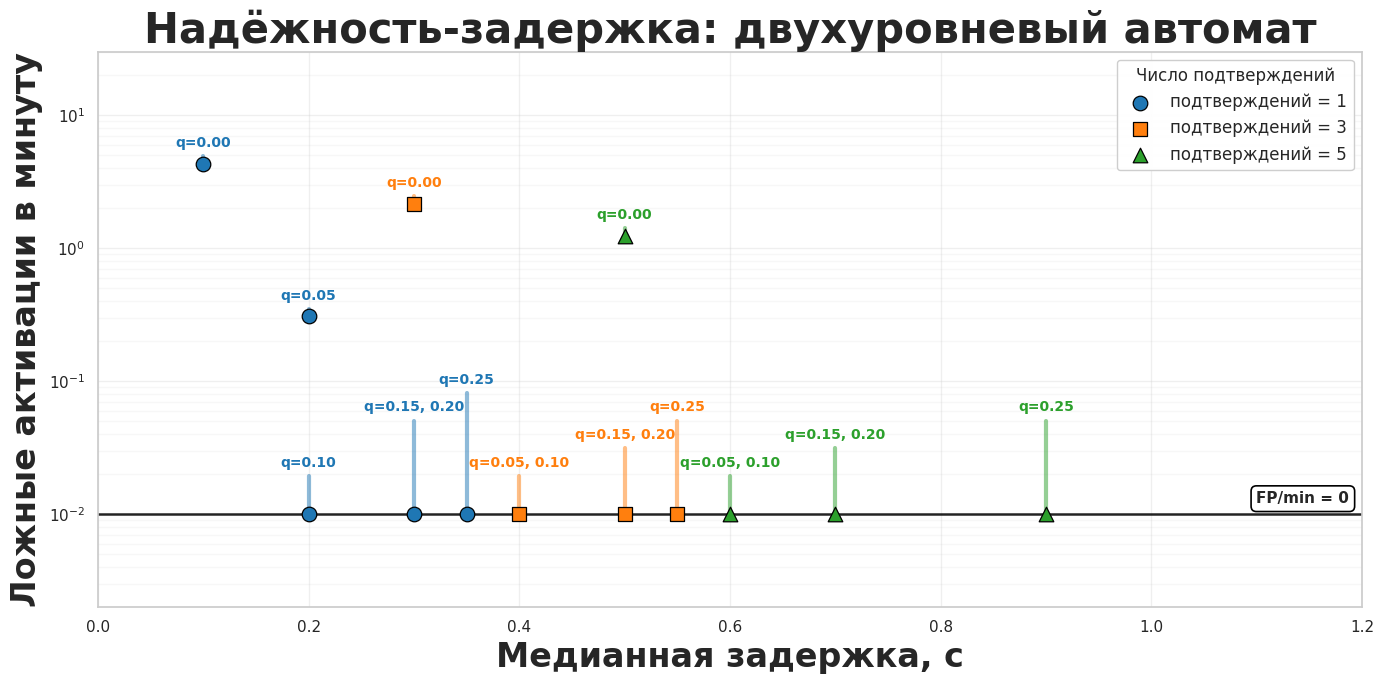

In [75]:
tradeoff = tuning.query("method == 'M4_two_level_automaton'").copy()

fig, ax = plt.subplots(figsize=(14, 7))

colors = {1: 'tab:blue', 3: 'tab:orange', 5: 'tab:green'}
markers = {1: 'o', 3: 's', 5: '^'}
EPS = 0.01
ROUND = 3

LEVEL_OFFSETS = [14, 34, 54, 74, 94]
X_SHIFTS      = [0, 0, 0, 0, 0]

for n, part in tradeoff.groupby('confirmations'):
    n = int(n)
    color = colors[n]

    part = part.copy()
    part['x_r'] = part.median_delay_s.round(ROUND)
    part['y_r'] = part.false_activations_per_min.clip(lower=EPS).round(ROUND)

    grouped = (part.groupby(['x_r', 'y_r'])['threshold']
                   .apply(lambda s: sorted(s.unique()))
                   .reset_index())

    xs = grouped.x_r.to_numpy()
    ys = grouped.y_r.to_numpy()

    ax.scatter(xs, ys, s=110, marker=markers[n], color=color,
               edgecolor='black', linewidth=0.9,
               label=f'подтверждений = {n}', zorder=4)

    for i, (_, row) in enumerate(grouped.iterrows()):
        qs = row.threshold
        if len(qs) == 1:
            label = f'q={qs[0]:.2f}'
        else:
            label = 'q=' + ', '.join(f'{q:.2f}' for q in qs)

        yy = row.y_r
        is_zero = yy == EPS

        if is_zero:
            level = i % len(LEVEL_OFFSETS)
            dy = LEVEL_OFFSETS[level]
            dx = X_SHIFTS[level]
            xytext = (dx, dy)
            ha = 'center'
        else:
            xytext, ha = (0, 12), 'center'

        ax.annotate(label,
                    xy=(row.x_r, yy),
                    xytext=xytext,
                    textcoords='offset points',
                    ha=ha, fontsize=10, color=color, fontweight='bold',
                    arrowprops=dict(
                        arrowstyle='-',
                        color=color,
                        lw=3,
                        alpha=0.5,
                        connectionstyle='angle,angleA=90,angleB=0,rad=0',
                    ))

ax.axhline(EPS, color='black', linestyle='-', linewidth=1.8,
           alpha=0.85, zorder=2)
ax.text(0.99, EPS * 1.15, 'FP/min = 0',
        transform=ax.get_yaxis_transform(),
        ha='right', va='bottom',
        fontsize=11, fontweight='bold',
        bbox=dict(boxstyle='round,pad=0.35',
                  facecolor='white', edgecolor='black', linewidth=1.2),
        zorder=5)

ax.set_yscale('log')
ax.set_ylim(EPS / 5, 30)
ax.set_xlim(0.0, 1.2)

ax.set_xlabel('Медианная задержка, с', fontweight='bold', fontsize=24)
ax.set_ylabel('Ложные активации в минуту',
              fontweight='bold', fontsize=24)
ax.set_title('Надёжность-задержка: двухуровневый автомат',
             fontweight='bold', fontsize=30)

ax.grid(True, which='both', alpha=0.3)
ax.grid(True, which='minor', alpha=0.15)
ax.legend(title='Число подтверждений', fontsize=12, title_fontsize=12,
          loc='upper right', framealpha=0.95)

fig.tight_layout()
fig.savefig(FIG_DIR / 'validation_reliability_delay.png',
            dpi=160, bbox_inches='tight')
plt.show()

**Вывод:** берём крайнию левую нижнию точку. Минимальная задержка 0 ложных активаций. Итого порог 0.10 и 1 окно смотрим

## Финальный расчёт на test

In [65]:
one_test = predict_one_level(X_test)
two_test, two_test_confidence = predict_two_level(X_test, with_confidence=True)

m2_test, _ = apply_per_record(one_test, test_slices, lambda x: causal_majority(x, best_window))
m4_test, m4_states = apply_per_record(two_test, test_slices, lambda x,c: transition_automaton(x,c,best_confirmations,best_threshold), two_test_confidence)

predictions = {'M1: 1-level, raw':one_test, f'M2: 1-level, majority (w={best_window})':m2_test, 'M3: 2-level, raw':two_test, f'M4: 2-level, automaton (n={best_confirmations}, q={best_threshold:.2f})':m4_test}
comparison = pd.DataFrame([{'method':name, **evaluate(y_test,pred,test_slices)} for name,pred in predictions.items()])
comparison.to_csv(RESULTS_DIR / 'test_method_comparison.csv', index=False)

display(comparison.round(3))

,method,frame_accuracy,event_precision,event_recall,event_f1,false_activations_per_min,median_delay_s,p95_delay_s,double_commands_per_transition,missed_commands,reference_events,predicted_events
0,"M1: 1-level, raw",0.538,0.513,0.975,0.672,5.790,0.4,0.51,0.0,1,40,76
1,"M2: 1-level, majority (w=5)",0.517,0.565,0.975,0.716,4.695,0.6,0.71,0.0,1,40,69
2,"M3: 2-level, raw",0.551,0.470,0.975,0.634,6.886,0.2,0.50,0.0,1,40,83
3,"M4: 2-level, automaton (n=1, q=0.10)",0.542,0.812,0.975,0.886,1.408,0.2,0.61,0.0,1,40,48


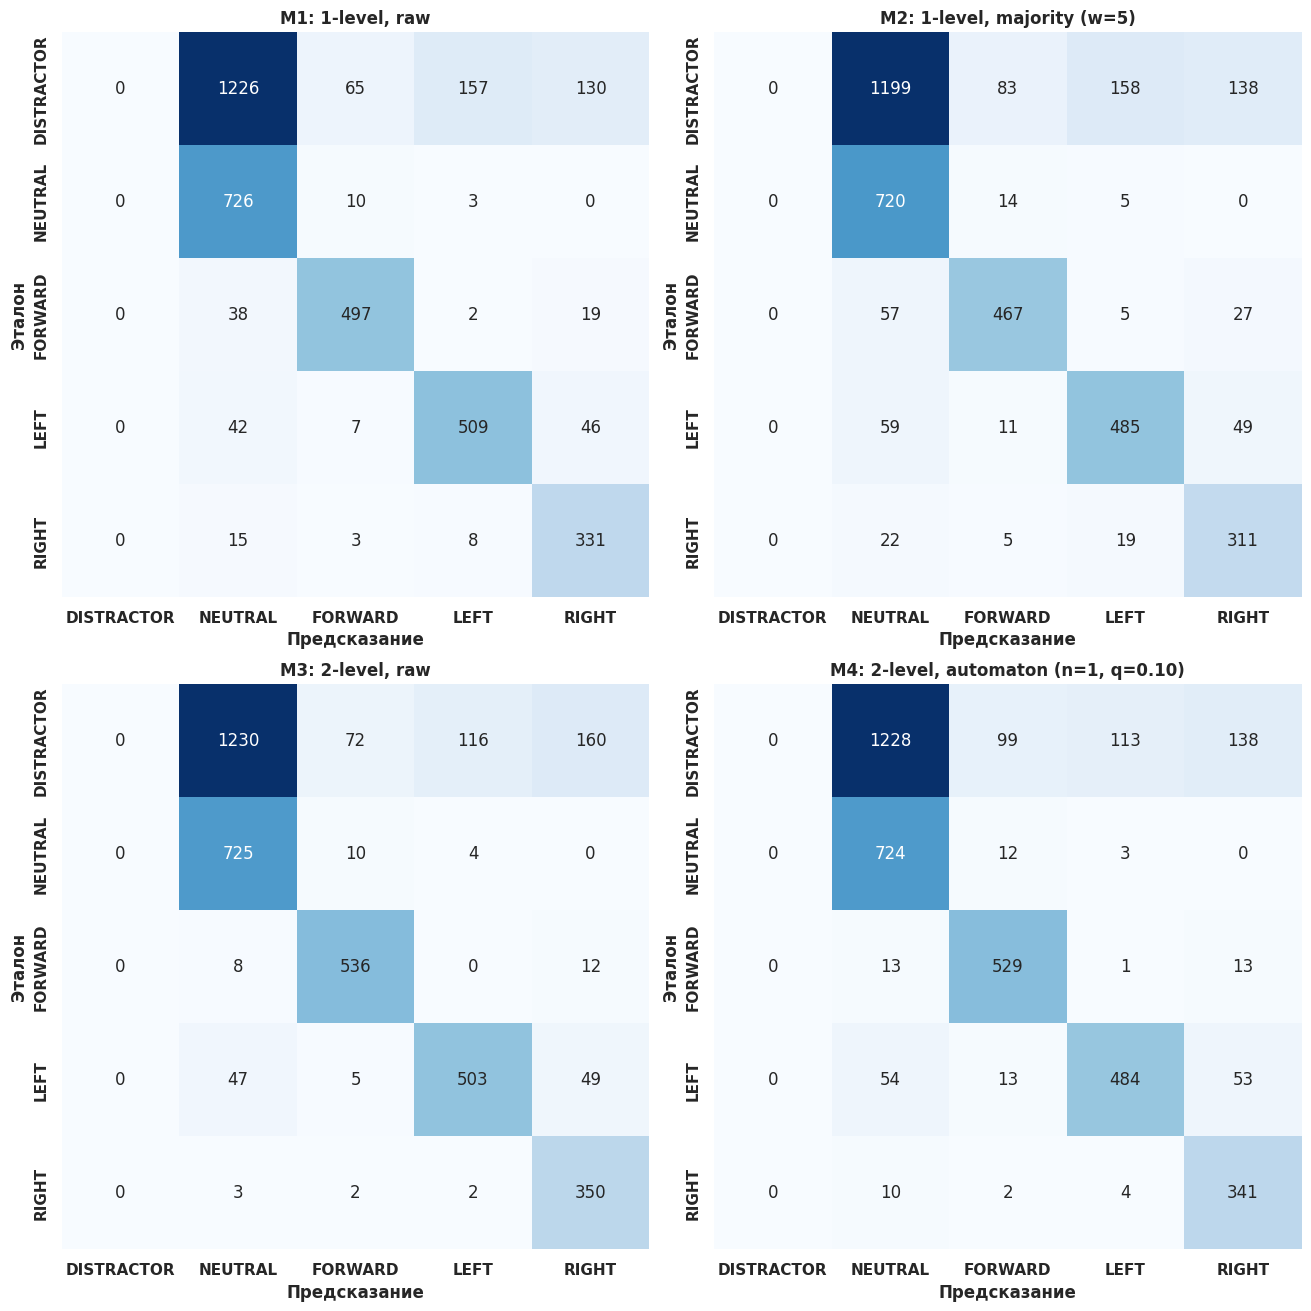

In [66]:
fig, axes = plt.subplots(2, 2, figsize=(13, 13), constrained_layout=True)

for ax, (name, pred) in zip(axes.flat, predictions.items()):
    cm = confusion_matrix(y_test, pred, labels=ALL_LABELS)

    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        cbar=False,
        ax=ax,
        xticklabels=[LABEL_NAMES[i] for i in ALL_LABELS],
        yticklabels=[LABEL_NAMES[i] for i in ALL_LABELS],
    )

    ax.set_title(name, fontweight='bold')
    ax.set_xlabel('Предсказание', fontweight='bold')
    ax.set_ylabel('Эталон', fontweight='bold')

    for label in ax.get_xticklabels() + ax.get_yticklabels():
        label.set_fontweight('bold')

fig.savefig(FIG_DIR / 'test_confusion_matrices.png', dpi=160)
plt.show()

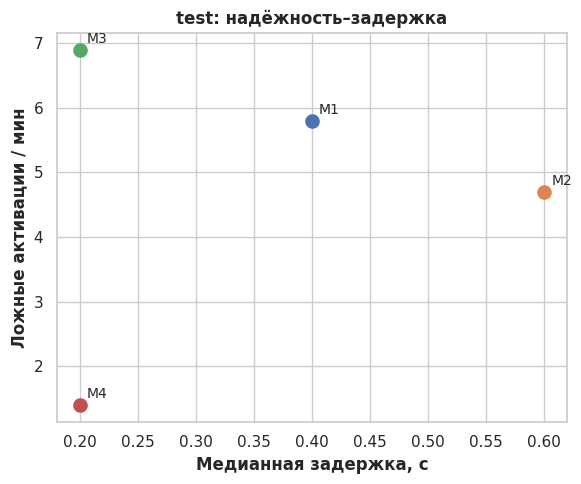

In [67]:
fig, ax = plt.subplots(figsize=(6, 5))

for _, row in comparison.iterrows():
    # точка
    ax.scatter(
        row.median_delay_s,
        row.false_activations_per_min,
        s=90,
        zorder=3,
    )
    # подпись рядом с точкой (M1, M2, M3, M4)
    ax.annotate(
        row.method.split(':')[0],
        (row.median_delay_s, row.false_activations_per_min),
        xytext=(5, 5),
        textcoords='offset points',
        fontsize=10,
    )

# жирные подписи осей и заголовок
ax.set_xlabel('Медианная задержка, с', fontweight='bold')
ax.set_ylabel('Ложные активации / мин', fontweight='bold')
ax.set_title('test: надёжность–задержка', fontweight='bold')

fig.tight_layout()
fig.savefig(FIG_DIR / 'test_reliability_delay.png', dpi=160)
plt.show()

**Вывод:** event_f1 у M4 с казуальным подтверждением лучший + false_activations_per_min минимальный. double_commands_per_transition = 0 - то есть стабильность, нет скачков. Метрики median_delay_s	p95_delay_s показываютч что доп задержка "в целом небольшая".

Итого у нас была ГИПОТЕЗА Явное состояние TRANSITION и подтверждение новой команды несколькими последовательными окнами уменьшают ложные активации и двойные переключения ценой небольшой дополнительной задержки.

**Итоговый результат: ГИПОТЕЗА НЕ ОПРОВЕРГНУТА.**

## Offline-демонстратор и автоматический тест каузальности

Воспроизводится первая тестовая запись: эталон, исходная VQ-метка, состояние автомата, найденные границы и накопленные переключения. Это только потенциальные высокоуровневые команды G1 - физическому роботу они не отправляются. Prefix-тест проверяет, что будущее не меняет прошлое решение.

In [68]:
def assert_causal(labels, confidence, confirmations, threshold):
    full, _ = transition_automaton(labels, confidence, confirmations, threshold)
    for end in range(1, len(labels) + 1):
        prefix, _ = transition_automaton(labels[:end], confidence[:end],
                                         confirmations, threshold)
        if not np.array_equal(prefix, full[:end]):
            raise AssertionError(f'Нарушение каузальности в окне {end}')
    return True

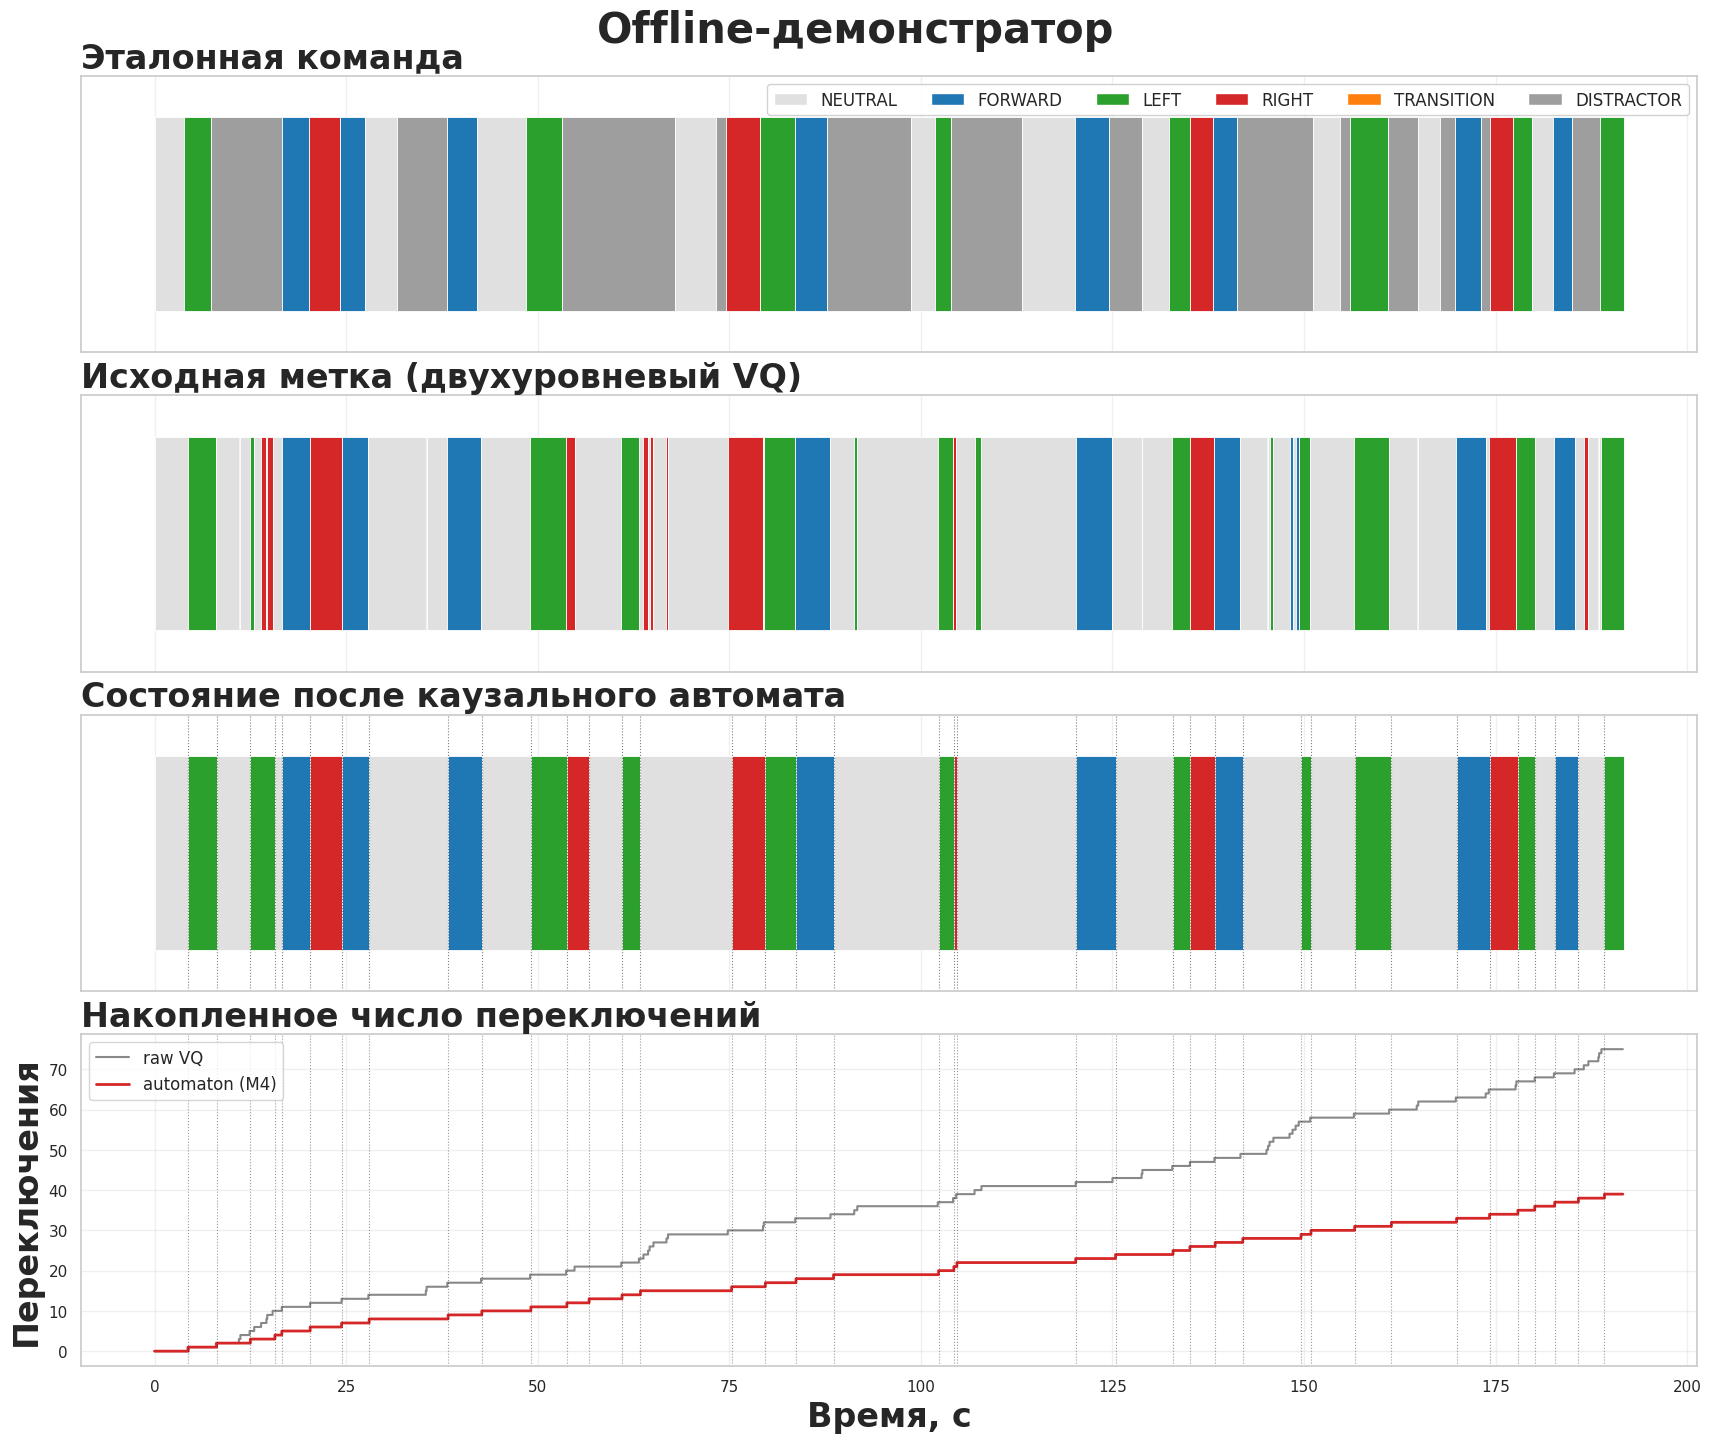

In [89]:
demo_slice = test_slices[0]
assert_causal(two_test[demo_slice], two_test_confidence[demo_slice],
              best_confirmations, best_threshold)

t = np.arange(demo_slice.stop - demo_slice.start) * WINDOW_STEP_SECONDS
reference = y_test[demo_slice]
raw = two_test[demo_slice]
stable = m4_test[demo_slice]
states = m4_states[demo_slice]

state_code = np.array([5 if s == 'TRANSITION' else p
                       for s, p in zip(states, stable)])

COLORS = {
    0: '#9e9e9e',   # DISTRACTOR — серый
    1: '#e0e0e0',   # NEUTRAL — светло-серый
    2: '#1f77b4',   # FORWARD — синий
    3: '#2ca02c',   # LEFT — зелёный
    4: '#d62728',   # RIGHT — красный
    5: '#ff7f0e',   # TRANSITION — оранжевый
}
LABELS = {0: 'DISTRACTOR', 1: 'NEUTRAL', 2: 'FORWARD',
          3: 'LEFT', 4: 'RIGHT', 5: 'TRANSITION'}

def draw_track(ax, values, y_offset=0.15, height=0.7):
    """Цветные полосы: одна на каждое непрерывное событие."""
    t0, i = 0, 0
    while i < len(values):
        start, cmd = i, int(values[i])
        while i < len(values) and int(values[i]) == cmd:
            i += 1
        ax.fill_between([start * WINDOW_STEP_SECONDS, i * WINDOW_STEP_SECONDS],
                        y_offset, y_offset + height,
                        color=COLORS[cmd], edgecolor='white', linewidth=0.6)

fig, axes = plt.subplots(4, 1, figsize=(17, 14), sharex=True,
                         constrained_layout=True,
                         gridspec_kw={'height_ratios': [1, 1, 1, 1.2]})

titles = ['Эталонная команда',
          'Исходная метка (двухуровневый VQ)',
          'Состояние после каузального автомата',
          'Накопленное число переключений']
tracks = [reference, raw, state_code]

for ax, values, title in zip(axes[:3], tracks, titles):
    draw_track(ax, values, y_offset=0.15, height=0.7)
    ax.set_ylim(0, 1)
    ax.set_yticks([])
    ax.set_title(title, fontweight='bold', loc='left', fontsize=24)
    ax.grid(axis='x', alpha=0.3)

legend_handles = [Patch(facecolor=COLORS[k], edgecolor='white',
                        label=LABELS[k]) for k in [1, 2, 3, 4, 5, 0]]
axes[0].legend(handles=legend_handles, loc='upper right',
               ncol=6, fontsize=12, framealpha=0.9)

def cumulative_switches(values):
    changes = values[1:] != values[:-1]
    return np.r_[0, np.cumsum(changes)]

axes[3].step(t, cumulative_switches(raw), where='post',
             linewidth=1.5, color='#888888', label='raw VQ')
axes[3].step(t, cumulative_switches(stable), where='post',
             linewidth=2.0, color='#d62728', label='automaton (M4)')
axes[3].legend(loc='upper left', fontsize=12)

stable_changes = np.flatnonzero(stable[1:] != stable[:-1]) + 1
for i, idx in enumerate(stable_changes):
    x = idx * WINDOW_STEP_SECONDS
    axes[2].axvline(x, color='black', linestyle=':', alpha=0.5, linewidth=0.8)
    axes[3].axvline(x, color='black', linestyle=':', alpha=0.4, linewidth=0.8)

axes[3].set_xlabel('Время, с', fontweight='bold', fontsize=24)
axes[3].set_ylabel('Переключения', fontweight='bold', fontsize=24)
axes[3].set_title('Накопленное число переключений', fontweight='bold', loc='left', fontsize=24)
axes[3].legend(loc='upper left', fontsize=12)
axes[3].grid(alpha=0.3)

fig.suptitle(f'Offline-демонстратор',
             fontweight='bold', y=1.02, fontsize=30)

fig.savefig(FIG_DIR / f'offline_demo_rec_{TEST_RECORD_IDS[0]}.png',
            dpi=160, bbox_inches='tight')
plt.show()

**Вывод:** Видно что казуальный автомат уменьшает 'дерганье'